In [ ]:
import re

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
df = pd.read_csv('../data/ground_truth_sample.csv')
df

,title,description,instructions,ingredients,photo_url,vegan,keto
0,"Grandma's Eggless, Butterless, Milkless Cake",You can get a moist chocolate cake without egg...,"['In a large bowl, combine all the dry ingredi...",['3 cups all-purpose flour' '2 cups white suga...,http://images.media-allrecipes.com/userphotos/...,True,False
1,Sweet and Spicy Turkey Rub,This dry rub recipe is an adaptation of a caju...,"['Combine brown sugar, garlic powder, red pepp...",['3 tablespoons brown sugar' '2 tablespoons ga...,http://images.media-allrecipes.com/userphotos/...,True,False
2,Marinated Mushrooms with Red Bell Peppers,This is perfect for a buffet or as a football ...,"['Combine the vinegar, water, oil, sugar, onio...",['1/2 cup red wine vinegar' '1/3 cup water' '2...,http://images.media-allrecipes.com/userphotos/...,True,False
3,Easy 4-Ingredient Margarita,This margarita is so easy to make and is absol...,['Fill a cocktail shaker with ice; add tequila...,"['1 cup ice cubes, or as needed' '1/3 cup tequ...",http://images.media-allrecipes.com/userphotos/...,True,False
4,Two Bowl Cake,"I don't remember when I got this recipe, but i...",['Preheat oven to 350 degrees F (175 degrees C...,['3 cups all-purpose flour' '2 cups white suga...,http://images.media-allrecipes.com/userphotos/...,True,False
...,...,...,...,...,...,...,...
95,Gingery Lemonade,"Spiked with plenty of fresh ginger, this spice...",['In an 8-quart saucepan combine SPLENDA(R) Gr...,"['1 1/2 cups SPLENDA® No Calorie Sweetener, Gr...",http://images.media-allrecipes.com/userphotos/...,True,True
96,Simple Cajun Seasoning,Here is a simple way to make Cajun seasoning u...,"['Combine the salt, oregano, paprika, cayenne ...",['2 1/2 tablespoons salt' '1 tablespoon dried ...,http://images.media-allrecipes.com/userphotos/...,True,True
97,Lemon-Basil Vinaigrette Corn Topper,Summer corn gets even better with a squeeze of...,"['Whisk lemon juice, oil and basil in a small ...",['1 tablespoon lemon juice' '2 teaspoons extra...,http://images.media-allrecipes.com/global/reci...,True,True
98,Dry Spice Rub for Lamb or Beef,I got this recipe from my grama. It can be use...,"['Mix together the paprika, thyme, basil, cumi...",['1 teaspoon paprika' '1 1/2 teaspoons dried t...,http://images.media-allrecipes.com/userphotos/...,True,True


In [3]:
parsed = df.ingredients.apply(lambda x: re.findall(r"'([^']+)'", x))
parsed

0     [3 cups all-purpose flour, 2 cups white sugar,...
1     [3 tablespoons brown sugar, 2 tablespoons garl...
2     [1/2 cup red wine vinegar, 1/3 cup water, 2 ta...
3     [1 cup ice cubes, or as needed, 1/3 cup tequil...
4     [3 cups all-purpose flour, 2 cups white sugar,...
                            ...                        
95    [1 1/2 cups SPLENDA® No Calorie Sweetener, Gra...
96    [2 1/2 tablespoons salt, 1 tablespoon dried or...
97    [1 tablespoon lemon juice, 2 teaspoons extra-v...
98    [1 teaspoon paprika, 1 1/2 teaspoons dried thy...
99    [2 pounds green beans, trimmed, 3 tablespoons ...
Name: ingredients, Length: 100, dtype: object

In [4]:
corpus = parsed.apply(lambda lst: " ".join(lst)).tolist()
len(corpus)

100

In [5]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)
tfidf_matrix.shape

(100, 340)

In [ ]:
# Convert sparse TF-IDF matrix to dense for PCA
X_dense = tfidf_matrix.toarray()
X_dense.shape

(100, 340)

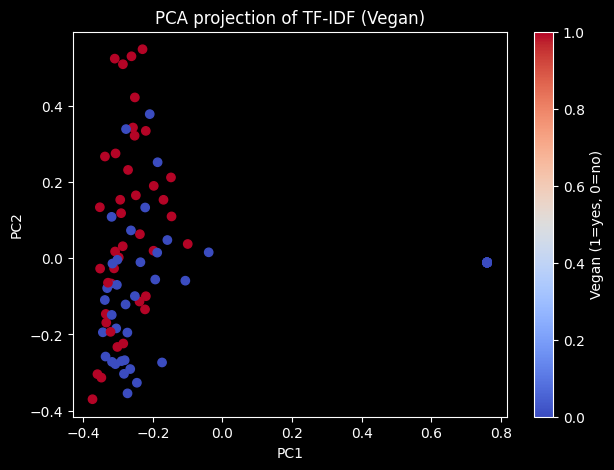

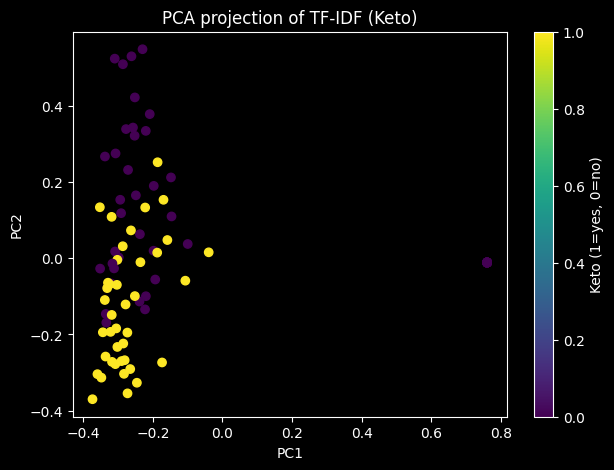

In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)

# --- PCA Vegan ---
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df.vegan, cmap='coolwarm')
plt.title("PCA projection of TF-IDF (Vegan)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Vegan (1=yes, 0=no)")
plt.show()

# --- PCA Keto ---
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df.keto, cmap='viridis')
plt.title("PCA projection of TF-IDF (Keto)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Keto (1=yes, 0=no)")
plt.show()

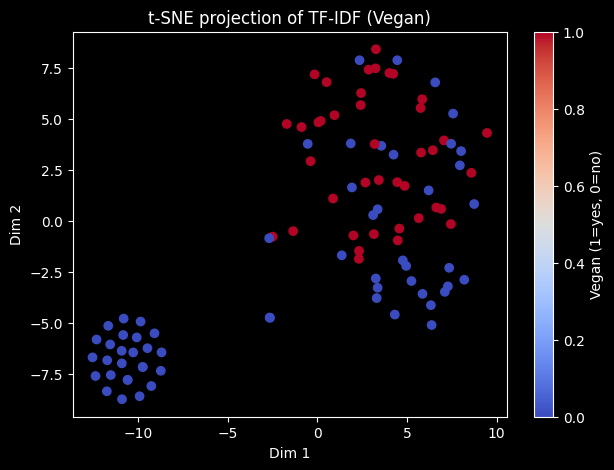

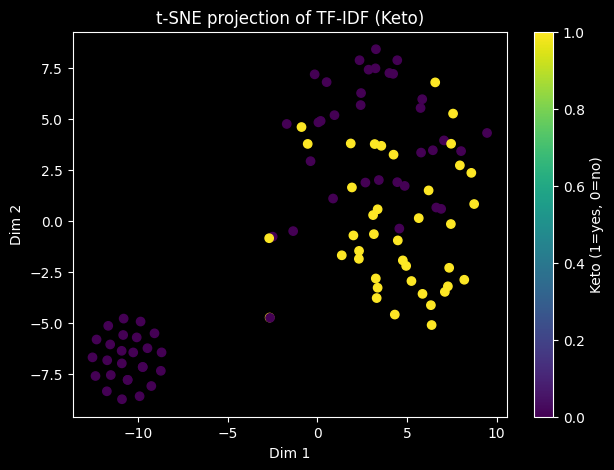

In [8]:
tsne = TSNE(n_components=2, perplexity=20, random_state=42)
X_tsne = tsne.fit_transform(X_dense)

# --- t-SNE Vegan ---
plt.figure(figsize=(7,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df.vegan, cmap='coolwarm')
plt.title("t-SNE projection of TF-IDF (Vegan)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(label="Vegan (1=yes, 0=no)")
plt.show()

# --- t-SNE Keto ---
plt.figure(figsize=(7,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df.keto, cmap='viridis')
plt.title("t-SNE projection of TF-IDF (Keto)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(label="Keto (1=yes, 0=no)")
plt.show()


In [ ]:
svd = TruncatedSVD(n_components=34, random_state=42)
X_reduced = svd.fit_transform(tfidf_matrix)
X_reduced.shape

(100, 34)

In [10]:
X_train_vegan, X_test_vegan, y_train_vegan, y_test_vegan = train_test_split(
    X_reduced, df.vegan, test_size=0.2, random_state=42
)

X_train_keto, X_test_keto, y_train_keto, y_test_keto = train_test_split(
    X_reduced, df.keto, test_size=0.2, random_state=42
)

In [17]:
def evaluate_classifiers(clf_vegan, clf_keto):
    clf_vegan.fit(X_train_vegan, y_train_vegan)
    clf_keto.fit(X_train_keto, y_train_keto)

    score_vegan = clf_vegan.score(X_test_vegan, y_test_vegan)
    score_keto = clf_keto.score(X_test_keto, y_test_keto)

    print(f'vagan score: {score_vegan}, keto score: {score_keto}')

In [ ]:

evaluators = [
    ( DecisionTreeClassifier(max_depth=5), DecisionTreeClassifier(max_depth=5), 'DecisionTreeClassifier' ),
    ( RandomForestClassifier(random_state=42, max_depth=5), RandomForestClassifier(random_state=42, max_depth=4), 'RandomForestClassifier' ),
    ( LogisticRegression(max_iter=500), LogisticRegression(max_iter=500), 'LogisticRegression' ),
    ( LinearSVC(), LinearSVC(), 'LinearSVC' ),
    ( KNeighborsClassifier(), KNeighborsClassifier(), 'KNeighborsClassifier' )
]


for tup in evaluators:
    (clf_vegan, clf_keto, eval_class) = tup
    
    print(f'Evaluating {eval_class}')
    evaluate_classifiers(clf_vegan, clf_keto)    
    print("\n")

Evaluating DecisionTreeClassifier
vagan score: 0.65, keto score: 0.6


Evaluating RandomForestClassifier
vagan score: 0.8, keto score: 0.9


Evaluating LogisticRegression
vagan score: 0.65, keto score: 0.95


Evaluating LinearSVC
vagan score: 0.75, keto score: 0.95


Evaluating KNeighborsClassifier
vagan score: 0.85, keto score: 1.0




In [39]:
def run_multinomial_vegan():
    X_train, X_test, y_train, y_test = train_test_split(
        tfidf_matrix, df.vegan, test_size=0.2, random_state=42
    )
    clf = MultinomialNB()
    clf.fit(X_train, y_train)
    return clf.score(X_test, y_test)

def run_multinomial_keto():
    X_train, X_test, y_train, y_test = train_test_split(
        tfidf_matrix, df.keto, test_size=0.2, random_state=42
    )
    clf = MultinomialNB()
    clf.fit(X_train, y_train)
    return clf.score(X_test, y_test)

score_vegan = run_multinomial_vegan()
score_keto = run_multinomial_keto()

print(f'score vegan: {score_vegan}, score keto: {score_keto}')

score vegan: 0.6, score keto: 0.95


### Conclusion

Best evaluator in this simple setting (wighout hiper-parameter optiomisation) is **KNeighborsClassifier**

vagan score: **0.85**, keto score: **1.0**